In [1]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm import tqdm
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from torch.utils.data import DataLoader,TensorDataset

/home/anmino/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
df = pd.read_csv(r"train.csv")

In [3]:
df = df.drop("id",axis=1)

In [4]:
df

,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...
749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


In [5]:
ohe = OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False)
encoded = ohe.fit_transform(df[["Sex"]])

In [6]:
encoded_col_name = ohe.get_feature_names_out()
encoded_col_name

array(['Sex_male'], dtype=object)

In [7]:
encoded_df = pd.DataFrame(encoded,columns=encoded_col_name)

In [8]:
encoded_df

,Sex_male
0,1.0
1,0.0
2,0.0
3,1.0
4,0.0
...,...
749995,1.0
749996,0.0
749997,1.0
749998,1.0


In [9]:
final_df = pd.concat(
    [df.drop("Sex",axis=1),encoded_df],
    axis=1
)

In [10]:


final_df

,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,Sex_male
0,36,189.0,82.0,26.0,101.0,41.0,150.0,1.0
1,64,163.0,60.0,8.0,85.0,39.7,34.0,0.0
2,51,161.0,64.0,7.0,84.0,39.8,29.0,0.0
3,20,192.0,90.0,25.0,105.0,40.7,140.0,1.0
4,38,166.0,61.0,25.0,102.0,40.6,146.0,0.0
...,...,...,...,...,...,...,...,...
749995,28,193.0,97.0,30.0,114.0,40.9,230.0,1.0
749996,64,165.0,63.0,18.0,92.0,40.5,96.0,0.0
749997,60,162.0,67.0,29.0,113.0,40.9,221.0,1.0
749998,45,182.0,91.0,17.0,102.0,40.3,109.0,1.0


In [11]:
x = final_df.drop("Calories",axis=1).values
y = final_df["Calories"].values

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

y_train_y_test_scaler = StandardScaler()
y_train = y_train_y_test_scaler.fit_transform(y_train.reshape(-1,1))
y_test = y_train_y_test_scaler.transform(y_test.reshape(-1,1))

In [14]:
joblib.dump(ohe,filename="OneHotEncoder.pkl")
joblib.dump(scaler,filename="x_train_x_test_scaler.pkl")
joblib.dump(y_train_y_test_scaler,filename="y_train_y_test_scaler.pkl")

['y_train_y_test_scaler.pkl']

In [15]:
x_train = torch.tensor(x_train,dtype=torch.float32)
x_test = torch.tensor(x_test,dtype=torch.float32)
y_train = torch.tensor(y_train,dtype=torch.float32)
y_test = torch.tensor(y_test,dtype=torch.float32)

In [16]:
train_dataset = TensorDataset(
    x_train,
    y_train
)

test_dataset = TensorDataset(
    x_test,
    y_test
)

In [17]:
train_loader = DataLoader(
    train_dataset,
    batch_size=100,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=100,
    shuffle=False
)

In [18]:
"""class GLUBlock(nn.Module):
    def __init__(self,dim):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(dim,dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
        )

        self.fc2 = nn.Sequential(nn.Linear(dim,dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
            nn.Dropout(0.1))
        self.fc3 = nn.Sequential(
            nn.Linear(dim,dim),
            nn.BatchNorm1d(dim),
            nn.GELU(),
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self,x):
        info = self.fc1(x)

        gate = self.fc2(x)
        gate = self.fc3(gate)
        gate = self.sigmoid(gate)

        out = info * gate
        return out
        

class ResidualBlock(nn.Module):
    def __init__(self,dim_d):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(dim_d,dim_d),
            nn.BatchNorm1d(dim_d),
            nn.GELU()
        )

        self.fc2 = nn.Sequential(
            nn.Linear(dim_d,dim_d),
            nn.BatchNorm1d(dim_d),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        self.fc3 = nn.Sequential(
            nn.Linear(dim_d,dim_d),
            nn.LayerNorm(dim_d),
            nn.GELU(),
            nn.Dropout(0.1)
        )

        self.glu = GLUBlock(dim=dim_d)

        self.gelu = nn.GELU()

    def forward(self,x):
        first = x
        out = self.fc1(x)
        out = self.fc2(x)
        out = self.fc3(out)

        #out = self.glu(out)

        out = out + first
        out = self.gelu(out)
        return out
    

class MyModel(nn.Module):
    def __init__(self,input_dim,output_dim):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.BatchNorm1d(output_dim),
            nn.GELU(),
            nn.Dropout(0.1)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(output_dim,output_dim),
            nn.BatchNorm1d(output_dim),
            nn.GELU()
        )

        self.fc3 = nn.Sequential(
            nn.Linear(output_dim,output_dim),
            nn.BatchNorm1d(output_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )

        self.attention = nn.Sequential(
            nn.Linear(output_dim ,output_dim),
            nn.BatchNorm1d(output_dim),
            nn.Linear(output_dim, output_dim),
            nn.BatchNorm1d(output_dim)
        )
        
        self.residual = ResidualBlock(dim_d=output_dim)
        
        self.output = nn.Linear(output_dim,1)
        self.gelu = nn.GELU()

    def forward(self,x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)

        attention = torch.sigmoid(self.attention(x))
        
        x = self.residual(x)
        x = attention * x
        

        x = self.gelu(x)
        x = self.output(x)
        
        return x"""
    

'class GLUBlock(nn.Module):\n    def __init__(self,dim):\n        super().__init__()\n\n        self.fc1 = nn.Sequential(\n            nn.Linear(dim,dim),\n            nn.BatchNorm1d(dim),\n            nn.GELU(),\n        )\n\n        self.fc2 = nn.Sequential(nn.Linear(dim,dim),\n            nn.BatchNorm1d(dim),\n            nn.GELU(),\n            nn.Dropout(0.1))\n        self.fc3 = nn.Sequential(\n            nn.Linear(dim,dim),\n            nn.BatchNorm1d(dim),\n            nn.GELU(),\n        )\n\n        self.sigmoid = nn.Sigmoid()\n\n    def forward(self,x):\n        info = self.fc1(x)\n\n        gate = self.fc2(x)\n        gate = self.fc3(gate)\n        gate = self.sigmoid(gate)\n\n        out = info * gate\n        return out\n        \n\nclass ResidualBlock(nn.Module):\n    def __init__(self,dim_d):\n        super().__init__()\n\n        self.fc1 = nn.Sequential(\n            nn.Linear(dim_d,dim_d),\n            nn.BatchNorm1d(dim_d),\n            nn.GELU()\n        )\n\n    

In [55]:
class ResidualBlock(nn.Module):
    def __init__(self,input_dim,output_dim):
        super().__init__()
        
        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )

        self.fc2 = nn.Sequential(nn.Linear(output_dim,output_dim),
                                 nn.LayerNorm(output_dim),
                                 nn.ReLU(),
                                 nn.Dropout(0.1))
    def forward(self,x):
        identi = x

        out = self.fc1(x)
        out = self.fc2(out)
        out = torch.sigmoid(out)
        out = out + identi
        return out
    
class ProjectionBlock(nn.Module):
    def __init__(self,input_dim,output_dim):
        super().__init__()

        self.shortcut = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )

        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(output_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(0.1)
        )

        self.residual = ResidualBlock(input_dim=output_dim,output_dim=output_dim)

        self.relu = nn.ReLU()

    def forward(self,x):
        identi = self.shortcut(x)

        out = self.fc1(x)

        out = out + identi
        out = self.relu(out)
        return out
    
class SEBlock(nn.Module):
    def __init__(self,input_dim,output_dim):
        super().__init__()

        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(output_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )

        self.projection = ProjectionBlock(input_dim=output_dim,output_dim=output_dim)

        self.relu = nn.ReLU()

    def forward(self,x):
        mean = x

        out = self.fc1(mean)
        out = self.fc2(out)

        out = self.projection(out)

        out = x * out
        out = self.relu(out)
        return out

    
class MyModel(nn.Module):
    def __init__(self,input_dim,output_dim):
        super().__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(input_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(output_dim,output_dim),
            nn.LayerNorm(output_dim),
            nn.ReLU()
        )

        self.se = SEBlock(input_dim=output_dim,output_dim=output_dim)

        self.relu = nn.ReLU()
        self.output = nn.Linear(output_dim,1)

    def forward(self,x):
        x = self.fc1(x)
        x = self.fc2(x)

        x = self.se(x)

        x = self.relu(x)
        x = self.output(x)
        return x

In [56]:
256//2

128

In [57]:
model = MyModel(input_dim=7,output_dim=256)

In [58]:
model.training

True

In [59]:
loss_function = nn.MSELoss()

optimizer_function = torch.optim.AdamW(model.parameters(),
                                       lr=0.001,
                                       weight_decay=0.01)

# Gradient Clipping remaining

In [60]:
train_loss_hist = []
test_loss_hist = []

epochs = 50
progress_bar = tqdm(range(epochs),colour="red",desc="Ann_Model")
for i in progress_bar:
    model.train()
    total_train_loss = 0

    for x_batch,y_batch in train_loader:
        optimizer_function.zero_grad()
        prediction = model(x_batch)
        loss = loss_function(prediction,y_batch)
        loss.backward()
        optimizer_function.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(train_loader)

    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for x_test,y_test in test_loader:
            test_prediction = model(x_test)
            test_loss = loss_function(test_prediction,y_test)
            total_test_loss += test_loss.item()

        avg_test_loss = total_test_loss / len(test_loader)
        train_loss_hist.append(avg_train_loss)
        test_loss_hist.append(avg_test_loss)

        torch.save({
            "Epochs":epochs,
            "Train_Loss":avg_train_loss,
            "Test_Loss":avg_test_loss,
            "Optimizer":optimizer_function.state_dict()
        },f"SEBlock/checkpoint_{i}.pth")

        progress_bar.set_postfix({
            "Epoch":i,
            "Tain_Loss":f"{avg_train_loss:.4f}",
            "Test_Loss":f"{avg_test_loss:.4f}"
        })


Ann_Model: 100%|██████████| 50/50 [59:56<00:00, 71.92s/it, Epoch=49, Tain_Loss=0.0039, Test_Loss=0.0185]


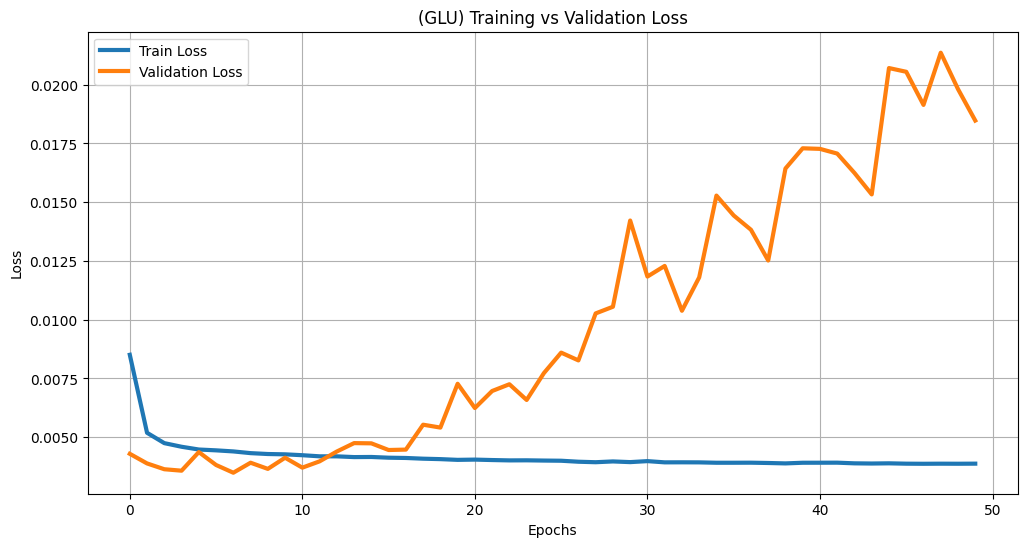

In [61]:
plt.figure(figsize=(12,6))

plt.plot(
    
    train_loss_hist,
    
    label="Train Loss",linewidth=3
)

plt.plot(
    
    test_loss_hist,
    
    label="Validation Loss",linewidth=3
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("(GLU) Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
model.eval()

predictions = []

actuals = []

with torch.no_grad():

    for x_batch, y_batch in test_loader:

        pred = model(x_batch)

        predictions.extend(
            
            pred.numpy().flatten()
        )

        actuals.extend(
            
            y_batch.numpy().flatten()
        )

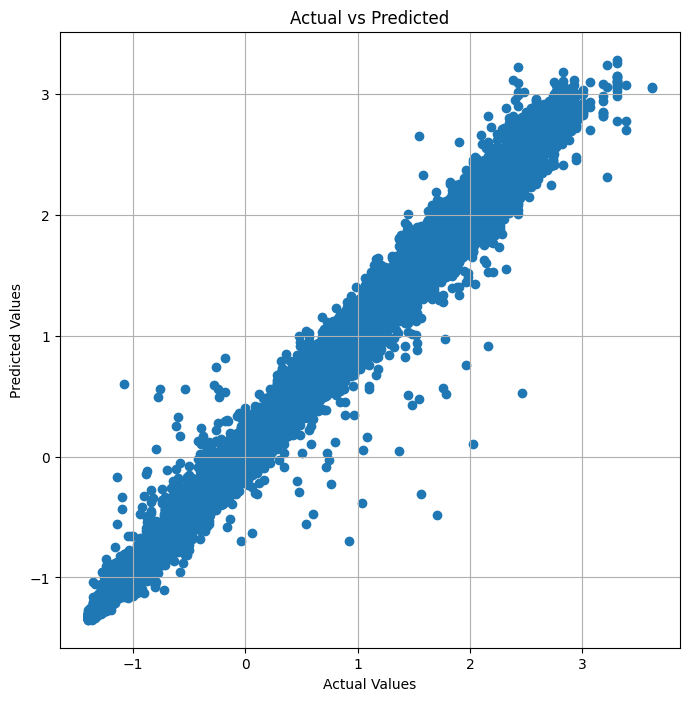

In [34]:
plt.figure(figsize=(8,8))

plt.scatter(
    
    actuals,
    
    predictions
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

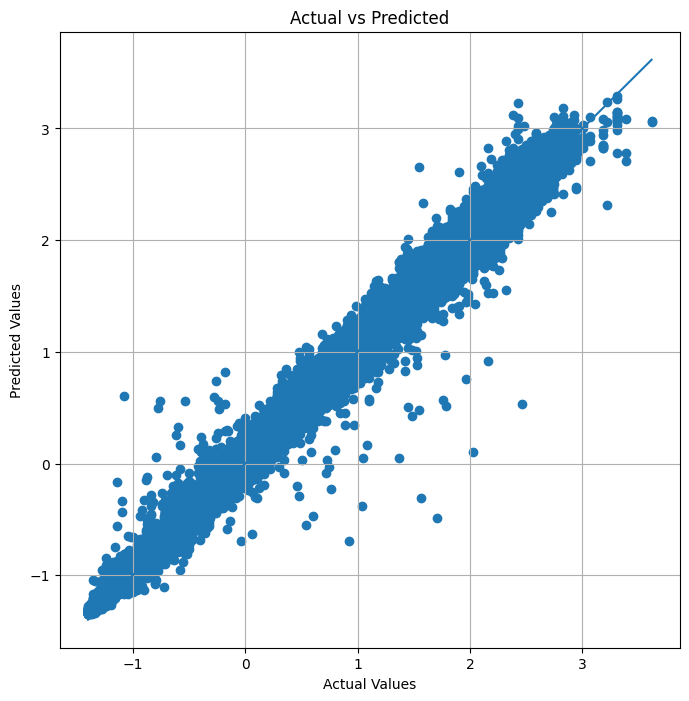

In [35]:
plt.figure(figsize=(8,8))

plt.scatter(
    
    actuals,
    
    predictions
)

plt.plot(
    
    [min(actuals), max(actuals)],
    
    [min(actuals), max(actuals)]
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

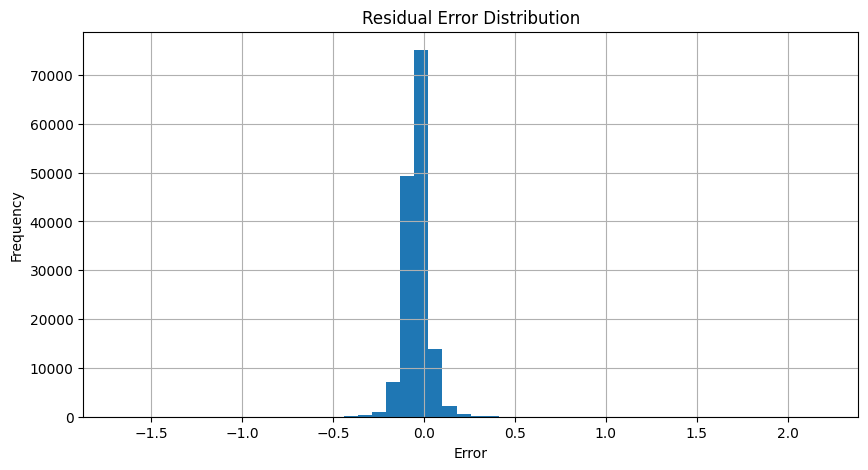

In [36]:
import numpy as np

errors = np.array(actuals) - np.array(predictions)

plt.figure(figsize=(10,5))

plt.hist(
    
    errors,
    
    bins=50
)

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.title("Residual Error Distribution")

plt.grid(True)

plt.show()

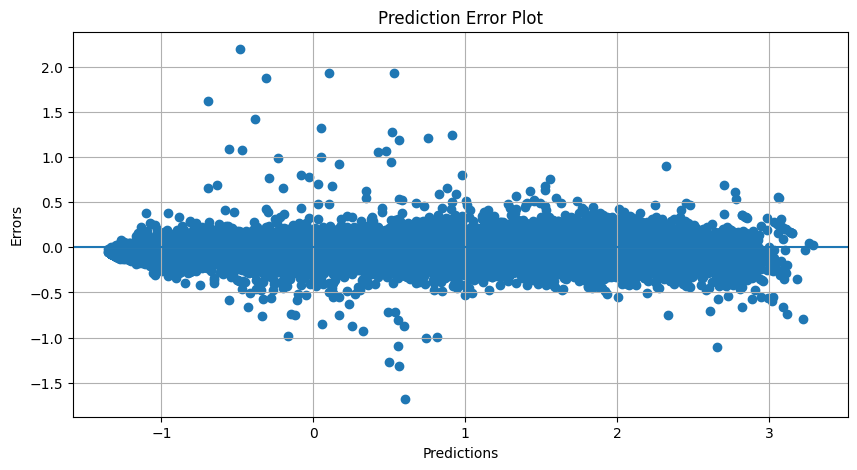

In [30]:
plt.figure(figsize=(10,5))

plt.scatter(
    
    predictions,
    
    errors
)

plt.axhline(
    
    y=0
)

plt.xlabel("Predictions")

plt.ylabel("Errors")

plt.title("Prediction Error Plot")

plt.grid(True)

plt.show()

In [31]:
results = {

    "Model": [

        "Linear Regression",

        "Random Forest",

        "ANN"
    ],

    "R2 Score": [

        0.81,

        0.89,

        0.93
    ]
}

In [32]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison["Model"],

    comparison["R2 Score"]
)

plt.title("Model Benchmark Comparison")

plt.ylabel("R2 Score")

plt.show()

NameError: name 'comparison' is not defined

<Figure size 800x500 with 0 Axes>